# 06 · Modelled structures — TCRpMHCmodels + Bigot (Rmd 7)

Reproduces `code_paper/7_Benchmark_models.Rmd` on the **2026 TCRen**. TCRen needs a 3D
structure, which is rarely available — so this asks whether it still works on **homology
models** (TCRpMHCmodels) instead of crystals.

**Part A** — for non-redundant complexes modelled *without* a near-identical TCR template
(best template identity < 85 %), we re-run the cognate-vs-random benchmark of notebook 02 on
the model's contact geometry and compare the cognate-epitope rank to the crystal-based rank
(Fig 3a), stratified by template identity (Fig 3b).

**Part B** — blind neoepitope ranking for 14 modelled patient TCRs from Bigot et al.: among
44 candidate 9-mers, where does each TCR's true cognate epitope rank?

In [1]:
import warnings; warnings.filterwarnings('ignore')
import glob, os
from pathlib import Path
import numpy as np, polars as pl
from tcren.paper import annotate_structure_set

R = 'results_new'
AA = list('LFIMVWYCHAGPTSQNDERK'); AIDX = {a: i for i, a in enumerate(AA)}

markup = pl.read_csv(f'{R}/markup_2026.csv')
peptide_of = {r['pdb.id']: r['peptide'] for r in markup.iter_rows(named=True) if r['peptide']}
loo = pl.read_csv(f'{R}/TCRen_2026_LOO.csv')
nonred = set(loo['pdb.id'].unique().to_list())
contacts_xtal = pl.read_csv(f'{R}/contacts_2026.csv')

def mat_from(df, vcol='value'):
    m = np.zeros((20, 20))
    for r in df.iter_rows(named=True):
        i, j = AIDX.get(r['residue.aa.from']), AIDX.get(r['residue.aa.to'])
        if i is not None and j is not None:
            m[i, j] = r[vcol]
    return m

loo_mat = {pid: mat_from(loo.filter(pl.col('pdb.id') == pid), 'TCRen.LOO') for pid in nonred}

def geom(ab, pid):
    sub = ab.filter(pl.col('pdb.id') == pid)
    pos = np.array(sub['pos.to'].to_list())
    tcr = np.array([AIDX.get(a, -1) for a in sub['residue.aa.from'].to_list()])
    keep = (pos >= 0) & (tcr >= 0)
    return pos[keep], tcr[keep]

def cognate_rank(pos, tcr, cog, M, rng, n=1000):
    """% of n anchor-preserving random decoys scoring below the cognate (lower = better)."""
    if not cog or len(cog) < 4 or any(a not in AIDX for a in cog):
        return None
    L = len(cog); keep = pos < L; pos2, tcr2 = pos[keep], tcr[keep]
    if len(pos2) == 0:
        return None
    cogv = np.array([AIDX[a] for a in cog])
    dec = rng.integers(0, 20, size=(n, L)); dec[:, 1] = cogv[1]; dec[:, L - 1] = cogv[L - 1]
    allp = np.vstack([cogv[None, :], dec])
    sc = M[tcr2[None, :], allp[:, pos2]].sum(axis=1)
    return float((sc[1:] < sc[0]).mean() * 100)

# TCR template identity per complex; keep non-redundant complexes modelled with <85% identity.
ti = {}
import tarfile, tempfile
_tcrp = tempfile.mkdtemp()
tarfile.open('data_legacy/TCRpMHCmodels.tar.gz').extractall(_tcrp)
for f in glob.glob(f'{_tcrp}/TCRpMHCmodels/*-complex-templates.csv.gz'):
    d = pl.read_csv(f)
    ti[os.path.basename(f)[:4]] = float(((d['tcrA_identity'] + d['tcrB_identity']) / 2).max())
pdb_models = [p for p, v in ti.items() if p in nonred and v < 85]
print(f'non-redundant complexes modelled with <85% TCR identity: {len(pdb_models)}')

non-redundant complexes modelled with <85% TCR identity: 47


In [2]:
# Part A: cognate rank on the MODEL geometry vs the CRYSTAL geometry (same complexes, TCRen LOO).
cmodel, _ = annotate_structure_set('../data/PolyV2022')   # poly-V models, one batched call
ab_model = cmodel.filter(pl.col('chain.type.from').is_in(['TRA', 'TRB']))
ab_xtal = contacts_xtal.filter(pl.col('chain.type.from').is_in(['TRA', 'TRB']))

rng = np.random.default_rng(0)
rows = []
for pid in pdb_models:
    cog = peptide_of.get(pid); M = loo_mat.get(pid)
    if M is None:
        continue
    rm = cognate_rank(*geom(ab_model, pid), cog, M, rng)
    rx = cognate_rank(*geom(ab_xtal, pid), cog, M, rng)
    if rm is None or rx is None:
        continue
    rows.append({'pdb.id': pid, 'tcr_identity': round(ti[pid], 1), 'model': rm, 'crystal': rx})
models_ranks = pl.DataFrame(rows)
models_ranks.write_csv(f'{R}/benchmark_models_ranks.csv')
print(f'scored {models_ranks.height} complexes')
print('median cognate rank  model: {:.0f}%  crystal: {:.0f}%'.format(
    models_ranks['model'].median(), models_ranks['crystal'].median()))
models_ranks.head()

scored 47 complexes
median cognate rank  model: 31%  crystal: 19%


pdb.id,tcr_identity,model,crystal
str,f64,f64,f64
"""6vma""",71.9,51.0,75.8
"""1nam""",30.6,70.0,11.3
"""7n6e""",60.6,37.9,66.9
"""1kj2""",32.9,64.6,67.8
"""6uon""",78.7,31.9,31.2


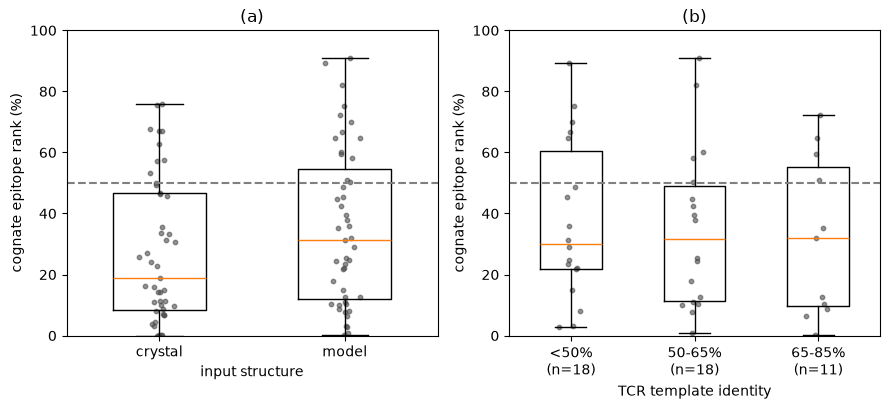

In [3]:
# Fig (a): model vs crystal cognate rank;  (b): model rank by TCR template-identity bin.
%matplotlib inline
import matplotlib.pyplot as plt

def bin_id(v):
    return '<50%' if v < 50 else ('50-65%' if v < 65 else '65-85%')

mr = models_ranks.with_columns(
    pl.col('tcr_identity').map_elements(bin_id, return_dtype=str).alias('bin'))
fig, (axa, axb) = plt.subplots(1, 2, figsize=(9, 4.2))

data_a = [models_ranks['crystal'].to_list(), models_ranks['model'].to_list()]
axa.boxplot(data_a, tick_labels=['crystal', 'model'], widths=0.5)
for i, d in enumerate(data_a, 1):
    axa.scatter(np.random.default_rng(1).normal(i, 0.04, len(d)), d, s=10, c='0.3', alpha=0.6)
axa.axhline(50, ls='--', c='grey'); axa.set_ylim(0, 100)
axa.set_ylabel('cognate epitope rank (%)'); axa.set_xlabel('input structure'); axa.set_title('(a)')

bins = ['<50%', '50-65%', '65-85%']
data_b = [mr.filter(pl.col('bin') == b)['model'].to_list() for b in bins]
axb.boxplot(data_b, tick_labels=[f'{b}\n(n={len(d)})' for b, d in zip(bins, data_b)], widths=0.5)
for i, d in enumerate(data_b, 1):
    axb.scatter(np.random.default_rng(2).normal(i, 0.04, len(d)), d, s=10, c='0.3', alpha=0.6)
axb.axhline(50, ls='--', c='grey'); axb.set_ylim(0, 100)
axb.set_ylabel('cognate epitope rank (%)'); axb.set_xlabel('TCR template identity'); axb.set_title('(b)')
plt.tight_layout()

In [4]:
# Part B: Bigot neoepitopes — rank each patient TCR's cognate among 44 candidate 9-mers (TCRen full).
M_full = mat_from(pl.read_csv(f'{R}/TCRen_2026.csv'))
cbig, _ = annotate_structure_set('../data/Bigot')
ab_big = cbig.filter(pl.col('chain.type.from').is_in(['TRA', 'TRB']))

candidates = pl.read_csv('data_legacy/Bigot/Bigot_candidate_epitopes.txt.gz')['peptide'].to_list()
# pdb.id is read as int from the CSV; model ids (from filenames) are strings — key on str.
cognate = {str(r['pdb.id']): r['cognate.peptide']
           for r in pl.read_csv('data_legacy/Bigot/Bigot_cognate_epitopes.csv.gz').iter_rows(named=True)}

def score(pos, tcr, pep, M):
    keep = pos < len(pep); p, t = pos[keep], tcr[keep]
    aa = np.array([AIDX[a] for a in pep])
    return float(M[t, aa[p]].sum())

bigot_rows = []; bigot_scores = {}
for pid in sorted(ab_big['pdb.id'].unique().to_list()):
    cog = cognate.get(str(pid))
    if not cog:
        continue
    peps = sorted(set(candidates) | {cog})
    pos, tcr = geom(ab_big, pid)
    sc = {p: score(pos, tcr, p, M_full) for p in peps if all(a in AIDX for a in p)}
    order = sorted(sc, key=sc.get)                          # ascending energy
    rank = order.index(cog) + 1
    bigot_rows.append({'pdb.id': pid, 'cognate': cog, 'rank': rank, 'n': len(sc)})
    bigot_scores[pid] = (sc, cog, rank)
bigot = pl.DataFrame(bigot_rows).sort('rank')
bigot.write_csv(f'{R}/benchmark_bigot.csv')
print(f'cognate in top-5 of 44 for {bigot.filter(pl.col("rank") <= 5).height}/{bigot.height} Bigot TCRs')
bigot

cognate in top-5 of 44 for 2/14 Bigot TCRs


pdb.id,cognate,rank,n
str,str,i64,i64
"""26992""","""LLIRWQHFL""",1,43
"""26995""","""ALLPGLPAA""",2,43
"""26990""","""RLPGVLPRA""",8,43
"""26998""","""ALLPGLPAA""",8,43
"""26993""","""AALPILFQV""",9,43
…,…,…,…
"""27010""","""RLGEVRHPV""",17,43
"""26994""","""ALLLQLFTL""",18,43
"""27009""","""RLPGVLPRA""",18,43


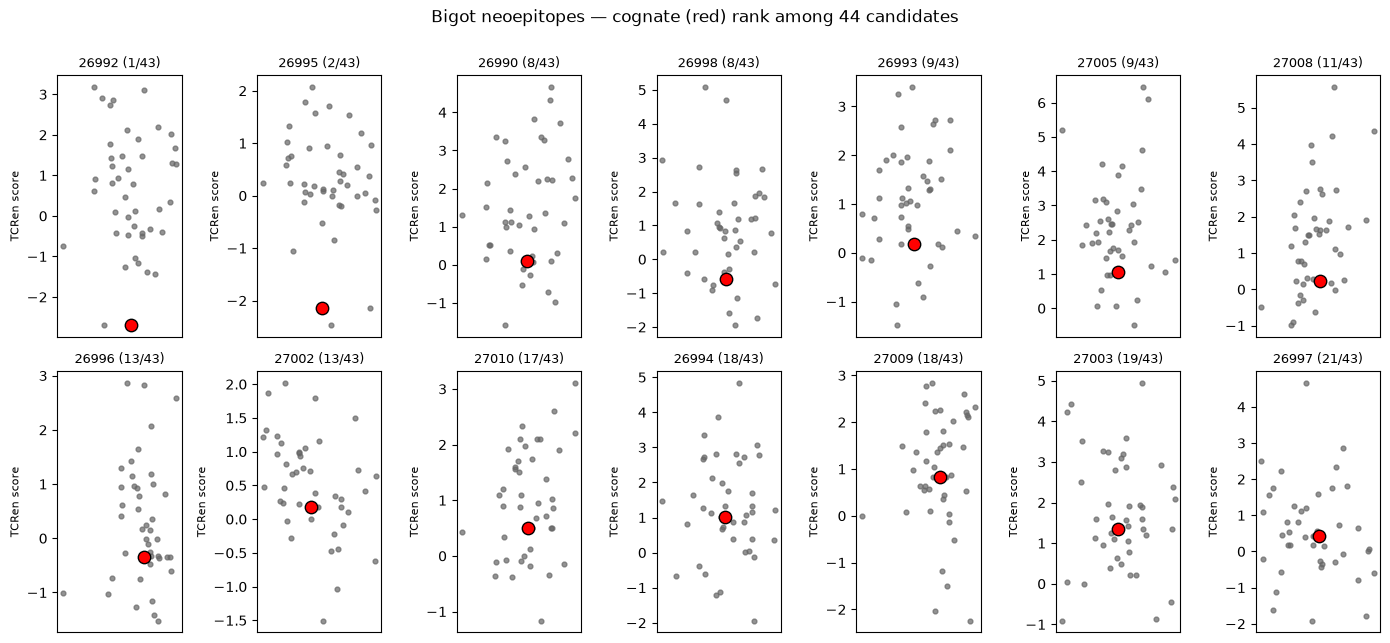

In [5]:
# Fig: per-TCR TCRen score distribution over candidate epitopes, cognate highlighted in red.
order = [r['pdb.id'] for r in bigot.iter_rows(named=True)]
ncol = 7; nrow = int(np.ceil(len(order) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(14, 3.2 * nrow), squeeze=False)
rng = np.random.default_rng(0)
for k, pid in enumerate(order):
    sc, cog, rank = bigot_scores[pid]
    ax = axes[k // ncol][k % ncol]
    vals = list(sc.values())
    ax.scatter(rng.normal(0, 0.05, len(vals)), vals, s=12, c='0.4', alpha=0.7)
    ax.scatter([0], [sc[cog]], s=80, c='red', zorder=5, edgecolor='k')
    ax.set_xticks([]); ax.set_title(f'{pid} ({rank}/{len(sc)})', fontsize=9)
    ax.set_ylabel('TCRen score', fontsize=8)
for k in range(len(order), nrow * ncol):
    axes[k // ncol][k % ncol].axis('off')
fig.suptitle('Bigot neoepitopes — cognate (red) rank among 44 candidates', y=1.0)
plt.tight_layout()